# A3 — Z-scores on a Subset

---

## 🔍 Problem-এ কী চাওয়া হয়েছে?

আমাদের কাছে একটি ছোট dataset আছে:

$$x = [8, 9, 11]$$

তিনটি কাজ করতে হবে — **ক্রমানুসারে**:

| ধাপ | কাজ |
|---|---|
| **১** | **Mean** ($\mu$) বের করা |
| **২** | **Population Standard Deviation** ($\sigma$) বের করা |
| **৩** | প্রতিটি মানের **Z-score** হিসাব করা |

> ⚠️ সুনির্দিষ্টভাবে বলা হয়েছে **population standard deviation** ব্যবহার করতে — sample std নয়।


---

## 🎯 এই কাজ থেকে আমরা কী অর্জন করতে পারব?

- **Mean** ও **Standard Deviation** হাতে হিসাব করার নিয়ম পাকা হবে।
- **Population vs Sample std**-এর পার্থক্য বুঝব — কোথায় কোনটি ব্যবহার হয়।
- **Z-score** কী বোঝায় — positive/negative/zero Z-score-এর intuition তৈরি হবে।
- Standardization-এর পর data-র **mean সবসময় 0** হয় এবং **std সবসময় 1** হয় — এটি verify করব।


---

## 🧠 আমরা যা শিখেছি, সেই আলোকে কীভাবে চিন্তা করতে হবে?

### Standardization (Z-score) formula:

$$z = \frac{x - \mu}{\sigma}$$

| Symbol | অর্থ |
|---|---|
| $x$ | মূল মান |
| $\mu$ | dataset-এর mean |
| $\sigma$ | dataset-এর **population** standard deviation |
| $z$ | Z-score (mean থেকে কত std দূরে আছে) |

### Population vs Sample Standard Deviation:

| | Population std | Sample std |
|---|---|---|
| **Formula** | $\sigma = \sqrt{\frac{\sum(x_i - \mu)^2}{N}}$ | $s = \sqrt{\frac{\sum(x_i - \mu)^2}{N-1}}$ |
| **Denominator** | $N$ (সব data দিয়ে ভাগ) | $N-1$ (Bessel's correction) |
| **কখন** | পুরো population জানা থাকলে | শুধু sample দিয়ে কাজ করলে |
| **NumPy** | `np.std(x, ddof=0)` | `np.std(x, ddof=1)` |

### Z-score-এর intuition:
- $z = 0$ → মানটি ঠিক mean-এ আছে
- $z > 0$ → মানটি mean-এর **উপরে**
- $z < 0$ → মানটি mean-এর **নিচে**
- $|z| = 1$ → মানটি mean থেকে ঠিক **১ standard deviation** দূরে


---

## 🛠️ Problem Solve করার Approach

**Step 1:** Data define করা।

**Step 2:** Mean হাতে হিসাব করা, তারপর code verify।

**Step 3:** Population std হাতে হিসাব করা, তারপর code verify।

**Step 4:** প্রতিটি মানের Z-score হাতে হিসাব করা, তারপর code verify।

**Step 5:** Standardization-এর পর mean=0, std=1 হয় কিনা confirm করা।


## Step 1: Data Define করা

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

x = np.array([8, 9, 11], dtype=float)
N = len(x)

print(f"x = {x}")
print(f"N = {N}")


x = [ 8.  9. 11.]
N = 3


`dtype=float` দেওয়া হয়েছে কারণ mean ও std হিসাবে দশমিক সংখ্যা আসবে।
`N = len(x)` → মোট কতটি মান আছে।


---

## Step 2: Mean ($\mu$) বের করা

$$\mu = \frac{\sum x_i}{N} = \frac{8 + 9 + 11}{3} = \frac{28}{3} = \mathbf{9.333}$$


In [2]:
mean_manual = (x[0] + x[1] + x[2]) / N
mean_numpy  = np.mean(x)

print(f"Manual mean : {mean_manual:.4f}")
print(f"NumPy  mean : {mean_numpy:.4f}")
print(f"Match       : {np.isclose(mean_manual, mean_numpy)}")


Manual mean : 9.3333
NumPy  mean : 9.3333
Match       : True


`np.mean(x)` → সব মান যোগ করে N দিয়ে ভাগ করে।
`np.isclose()` → floating point-এর সামান্য পার্থক্য সহ দুটো মান সমান কিনা check করে।


---

## Step 3: Population Standard Deviation ($\sigma$) বের করা

$$\sigma = \sqrt{\frac{\sum(x_i - \mu)^2}{N}}$$

**প্রতিটি মানের জন্য $(x_i - \mu)^2$ বের করি:**

| $x_i$ | $x_i - \mu$ | $(x_i - \mu)^2$ |
|---|---|---|
| 8 | $8 - 9.333 = -1.333$ | $(-1.333)^2 = 1.778$ |
| 9 | $9 - 9.333 = -0.333$ | $(-0.333)^2 = 0.111$ |
| 11 | $11 - 9.333 = 1.667$ | $(1.667)^2 = 2.778$ |

$$\sum(x_i - \mu)^2 = 1.778 + 0.111 + 2.778 = 4.667$$

$$\sigma = \sqrt{\frac{4.667}{3}} = \sqrt{1.556} \approx \mathbf{1.247}$$


In [4]:
deviations    = x - mean_numpy
sq_deviations = deviations ** 2
variance      = sq_deviations.sum() / N          # population variance (ddof=0)
std_manual    = np.sqrt(variance)

std_numpy = np.std(x, ddof=0)                    # ddof=0 → population std

dev_table = pd.DataFrame({
    'x_i':              x.astype(int),
    'x_i - mean':       deviations.round(4),
    '(x_i - mean)^2':  sq_deviations.round(4)
})

print("── Deviation Table ──")
print(dev_table.to_string(index=False))
print(f"Sum of squared deviations : {sq_deviations.sum():.4f}")
print(f"Variance (sum / N)        : {variance:.4f}")
print(f"Manual std (sqrt var)     : {std_manual:.4f}")
print(f"NumPy  std (ddof=0)       : {std_numpy:.4f}")
print(f"Match                     : {np.isclose(std_manual, std_numpy)}")


── Deviation Table ──
 x_i  x_i - mean  (x_i - mean)^2
   8     -1.3333          1.7778
   9     -0.3333          0.1111
  11      1.6667          2.7778
Sum of squared deviations : 4.6667
Variance (sum / N)        : 1.5556
Manual std (sqrt var)     : 1.2472
NumPy  std (ddof=0)       : 1.2472
Match                     : True


`x - mean_numpy` → প্রতিটি মান থেকে mean বাদ দেওয়া (NumPy broadcasting)।
`** 2` → প্রতিটি deviation-কে বর্গ করা।
`ddof=0` → **population std** (N দিয়ে ভাগ)। `ddof=1` হলে sample std (N-1 দিয়ে ভাগ)।


---

## Step 4: Z-score হিসাব করা

$$z = \frac{x - \mu}{\sigma} = \frac{x - 9.333}{1.247}$$

### প্রতিটি মানের Z-score:

**$x = 8$:**
$$z = \frac{8 - 9.333}{1.247} = \frac{-1.333}{1.247} = \mathbf{-1.069}$$
→ mean-এর **নিচে** প্রায় ১ std

**$x = 9$:**
$$z = \frac{9 - 9.333}{1.247} = \frac{-0.333}{1.247} = \mathbf{-0.267}$$
→ mean-এর সামান্য **নিচে**

**$x = 11$:**
$$z = \frac{11 - 9.333}{1.247} = \frac{1.667}{1.247} = \mathbf{+1.336}$$
→ mean-এর **উপরে** প্রায় ১.৩ std


In [5]:
z_manual = (x - mean_numpy) / std_numpy

result = pd.DataFrame({
    'x':              x.astype(int),
    'x - mean':       deviations.round(4),
    'sigma':          [round(std_numpy, 4)] * N,
    'Z-score':        z_manual.round(4)
})

print("── Z-score Table ──")
print(result.to_string(index=False))


── Z-score Table ──
 x  x - mean  sigma  Z-score
 8   -1.3333 1.2472  -1.0690
 9   -0.3333 1.2472  -0.2673
11    1.6667 1.2472   1.3363


`(x - mean_numpy) / std_numpy` → element-wise বিয়োগ ও ভাগ — NumPy broadcasting-এর মাধ্যমে একসাথে সব মানের Z-score বের হয়।


---

## Step 5: Verify — Standardization-এর পর Mean = 0, Std = 1?

Standardization-এর একটি গুরুত্বপূর্ণ property:
> Z-scored data-র mean **সবসময় 0** এবং std **সবসময় 1** হয়।


In [7]:
z_mean = np.mean(z_manual)
z_std  = np.std(z_manual, ddof=0)

print(f"Z-scores         : {z_manual.round(4)}")
print(f"Mean of Z-scores : {z_mean:.10f}  (expected: 0)")
print(f"Std  of Z-scores : {z_std:.10f}  (expected: 1)")
print()
print(f"Mean ≈ 0 : {np.isclose(z_mean, 0)}")
print(f"Std  ≈ 1 : {np.isclose(z_std,  1)}")


Z-scores         : [-1.069  -0.2673  1.3363]
Mean of Z-scores : -0.0000000000  (expected: 0)
Std  of Z-scores : 1.0000000000  (expected: 1)

Mean ≈ 0 : True
Std  ≈ 1 : True


Mean-এর value ঠিক 0 না হয়ে **~0.0000000000** হবে — এটি floating point arithmetic-এর সামান্য error, বাস্তবে 0-ই।
`np.isclose()` এই সামান্য পার্থক্য সহ্য করে `True` দেখাবে। ✅

এই property-র কারণেই বিভিন্ন unit-এর features (যেমন kg ও cm) standardization-এর পরে **directly compare** করা যায়।


## Bonus: Visual — Original vs Z-scored

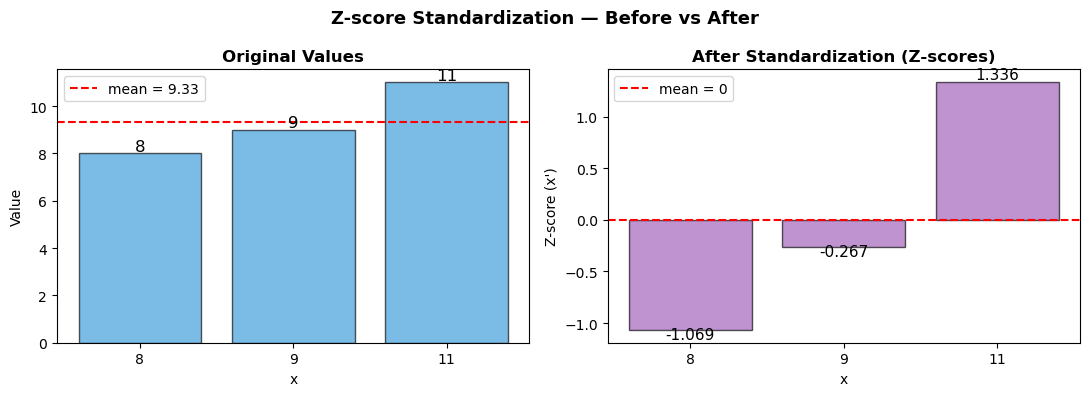

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels = [str(int(v)) for v in x]

# Original
axes[0].bar(labels, x, color='#3498db', alpha=0.65, edgecolor='black')
axes[0].axhline(mean_numpy, color='red', linestyle='--', linewidth=1.5, label=f'mean = {mean_numpy:.2f}')
axes[0].set_title('Original Values', fontweight='bold')
axes[0].set_ylabel('Value'); axes[0].set_xlabel('x')
axes[0].legend()
for i, v in enumerate(x):
    axes[0].text(i, v + 0.1, str(int(v)), ha='center', fontsize=12)

# Z-scored
axes[1].bar(labels, z_manual, color='#9b59b6', alpha=0.65, edgecolor='black')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5, label='mean = 0')
axes[1].set_title('After Standardization (Z-scores)', fontweight='bold')
axes[1].set_ylabel("Z-score (x')"); axes[1].set_xlabel('x')
axes[1].legend()
for i, v in enumerate(z_manual):
    offset = 0.03 if v >= 0 else -0.08
    axes[1].text(i, v + offset, f'{v:.3f}', ha='center', fontsize=11)

plt.suptitle('Z-score Standardization — Before vs After', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


Chart-এ লাল dashed line হলো **mean**।
- **Before**: mean = 9.333 — bars বিভিন্ন উচ্চতায়।
- **After**: mean = 0 — negative Z-score মানে bar নিচে, positive মানে উপরে।

Bar-এর relative ব্যবধান **হুবহু একই** — শুধু reference point (mean) শূন্যে সরে এসেছে।


---